<a href="https://colab.research.google.com/github/dchandr4/dsa405-project/blob/main/DSA405_002_FA26_P2_dchandr4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# P2: Data Audit, Cleaning Log & Provenance Brief
**DSA 405 · Fall 2026 · Project Milestone 2**

Name: Dhikshitha Chandrasekar  |  Unity ID: dchandr4



## 0. Setup and loading the raw file

The raw EPA file is stored unmodified in `data/raw/` of my GitHub repository (https://github.com/dchandr4/dsa405-project). The notebook reads it from that web address, so the code can never change the raw file. The EPA link is used only as a backup if GitHub cannot be reached.

In [1]:
import io, os, re, urllib.request
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

UA = "DSA405-student-project/1.0 (NC State class exercise; dchandr4@ncsu.edu)"
RAW_FILE   = "model-year-2024-fuel-economy-and-technology-data.csv"

# Raw data is stored unmodified in data/raw/ of my GitHub repo.
# Reading it from a web address means this notebook can never change it.
GITHUB_RAW = "https://raw.githubusercontent.com/dchandr4/dsa405-project/main/data/raw/" + RAW_FILE
EPA_URL    = "https://www.epa.gov/system/files/other-files/2026-05/" + RAW_FILE   # backup only

def fetch_raw_bytes():
    """Read the raw file from my GitHub repo; use the EPA link only if GitHub cannot be reached."""
    for url in [GITHUB_RAW, EPA_URL]:
        try:
            req = urllib.request.Request(url, headers={"User-Agent": UA})
            with urllib.request.urlopen(req, timeout=60) as r:
                return r.read(), url
        except Exception as e:
            print(f"Could not read {url}: {e}")
    raise RuntimeError("Raw file could not be read from GitHub or EPA.")

raw_bytes, SOURCE = fetch_raw_bytes()
print("Read from:", SOURCE)
print(f"File size: {len(raw_bytes)/1024:,.0f} KB")

Read from: https://raw.githubusercontent.com/dchandr4/dsa405-project/main/data/raw/model-year-2024-fuel-economy-and-technology-data.csv
File size: 1,827 KB


In [2]:
# (a) The file exactly as pandas loads it with default settings -> used only to report "dtype as loaded".
raw_default = pd.read_csv(io.BytesIO(raw_bytes), low_memory=False)

# (b) The audit copy: every value kept as the exact text in the file. Nothing is guessed or converted,
#     and text such as "NA" is NOT turned into a missing value.
raw = pd.read_csv(io.BytesIO(raw_bytes), dtype=str, keep_default_na=False, encoding="utf-8-sig")

assert raw.shape == raw_default.shape, "The two reads disagree on shape"
assert not raw.columns.duplicated().any(), "Duplicate column names in the raw file"
dtype_loaded = dict(zip(raw.columns, raw_default.dtypes.astype(str)))

ROWS_RAW, COLS_RAW = raw.shape
print(f"Raw file: {ROWS_RAW:,} rows x {COLS_RAW} columns")

# Cross-check against the numbers recorded in P1 (run Sep/Oct 2026): same file, nothing changed since.
P1 = {"rows": 1978, "columns": 164, "manufacturers": 27, "hybrid_flag_rows": 536}
now = {"rows": ROWS_RAW, "columns": COLS_RAW,
       "manufacturers": raw["CAFE Mfr Name"].nunique(),
       "hybrid_flag_rows": int((raw["HYBRID_YN"] == "Y").sum())}
print(pd.DataFrame({"P1": P1, "now": now}).assign(same=lambda t: t["P1"] == t["now"]))
raw.head(3)

Raw file: 1,978 rows x 164 columns
                    P1   now  same
rows              1978  1978  True
columns            164   164  True
manufacturers       27    27  True
hybrid_flag_rows   536   536  True


,MODEL_YEAR,CAFE Mfr Name,CAFE Mfr Code,Compliance Category,Compliance Category Desc,Carline Mfr Code,Carline Mfr Name,DIVISION_CD,MFR_DIVISION_SHORT_NM,CARLINE_CODE,CARLINE_NAME,MODEL_TYPE_INDEX,CARLINE_CLASS,CARLINE_CLASS_DESC,AVG_PASSENGER_VOL,AVG_LUGGAGE_VOL,TWO_DOOR_PASSENGER_VOL,TWO_DOOR_LUGGAGE_VOL,FOUR_DOOR_PASSENGER_VOL,FOUR_DOOR_LUGGAGE_VOL,HATCHBACK_PASSENGER_VOL,HATCHBACK_LUGGAGE_VOL,TRANS_TYPE,TRANS_TYPE_DESC,TRANS_TYPE_IF_OTHER,DRIVE_SYSTEM,DRIVE_SYSTEM_DESC,TRANS_LOCKUP_YN,TRANS_CREEPER_GEAR_YN,TOTAL_NUM_TRANS_GEARS,...,Batt Specific Energy,Batt Charger Type,Batt Charger Type Desc,Comments,# Capacitors,Regen Braking Type,Regen Braking Type Desc,Regen Braking Type; If Other,Regen Braking Source,Regen Braking Source Desc,Driver Cntrl Regen Braking?,Fuel Cell Desc,Usable H2 Fill Capacity,Fuel Cell Onboard H2 Capacity,HEV-EV Comments,EXH_STD_LVL,EXH_STD_LVL_DESC,EPA_VEH_CLS,EPA_VEH_CLS_DESC,CARLINE_BASE_LEVEL_PROD_VOL,CARLINE_BASE_LVL_GHG_PROD_VOL,BASE_LEVEL_PROD_VOL,SBCNFG_CARLINE_TESTGROUP,SBCNFG_TESTGROUP_PROD_VOL,Model_Type_Actual_Prod_Vol,CALC_GHG_PROD_VOLUME,CALC_CAFE_TEST_VOLUME,MODEL_TYPE_DRIVING_RANGE,Mech Variable Compress Ratio,PHEV_COMPOSITE_COMB_MPGE
0,2024,"American Honda Motor Co., Inc.",HNX,LT,Light Trucks,HNX,"American Honda Motor Co., Inc.",2,Acura,1,MDX AWD,501,31,Small SUV 4WD,,,,,,,,,SA,Semi-Automatic,,A,All Wheel Drive,Y,N,10,...,,,,,,,,,,,,,,,,T3B70,Federal Tier 3 Bin 70,LDT2,"LDT2 (LVW 3751-5750, GVW 0-6000)",36307,36307,36307,RHNXT03.5CCC,36307,36307,36307,36307,,N,
1,2024,"American Honda Motor Co., Inc.",HNX,LT,Light Trucks,HNX,"American Honda Motor Co., Inc.",2,Acura,4,MDX AWD Type-S,506,33,Standard SUV 4WD,,,,,,,,,SA,Semi-Automatic,,A,All Wheel Drive,Y,N,10,...,,,,,,,,,,,,,,,,T3B70,Federal Tier 3 Bin 70,LDT3,"LDT3 (ALVW 3751-5750, LVW 0-3750, GVW > 6000)",4706,4706,4706,RHNXT03.0HTC,4706,4706,4706,4706,,N,
2,2024,"American Honda Motor Co., Inc.",HNX,LT,Light Trucks,HNX,"American Honda Motor Co., Inc.",2,Acura,2,MDX FWD,502,30,Small SUV 2WD,,,,,,,,,SA,Semi-Automatic,,F,"2-Wheel Drive, Front",Y,N,10,...,,,,,,,,,,,,,,,,T3B70,Federal Tier 3 Bin 70,LDT2,"LDT2 (LVW 3751-5750, GVW 0-6000)",8378,8378,8378,RHNXT03.5CCC,8378,8378,8378,8378,,N,


*What these cells do:* the file is read twice. `raw_default` is the way pandas reads it with no options; it is used only to report the type pandas *guesses* for each column. `raw` reads every value as plain text (`dtype=str`) and keeps text such as `NA` as text (`keep_default_na=False`), so nothing is converted or lost before the audit has looked at it. The table compares the file with the numbers recorded in P1, to confirm it is the same file.

## 1. The audit

The file has more than 160 columns. The analysis uses the 34 listed below; the audit covers each of them, and several defect checks scan **every** column.

In [3]:
# Automatically restore/load raw data in case of kernel restart or out-of-order execution
if 'raw' not in globals() or 'raw_default' not in globals():
    import io
    import pandas as pd
    print("Initializing 'raw' and 'raw_default' dataframes...")
    raw_default = pd.read_csv(io.BytesIO(raw_bytes), low_memory=False)
    raw = pd.read_csv(io.BytesIO(raw_bytes), dtype=str, keep_default_na=False, encoding="utf-8-sig")

# raw column name -> name in the cleaned data
KEEP = {
    "MODEL_YEAR": "model_year",
    "CAFE Mfr Name": "mfr_name",
    "CAFE Mfr Code": "mfr_code",
    "Compliance Category": "compliance_category",
    "MFR_DIVISION_SHORT_NM": "division",
    "CARLINE_CODE": "carline_code",
    "CARLINE_NAME": "carline_name",
    "MODEL_TYPE_INDEX": "model_type_index",
    "CARLINE_CLASS_DESC": "carline_class",
    "EPA_VEH_CLS": "epa_vehicle_class",
    "TRANS_TYPE": "trans_type",
    "DRIVE_SYSTEM": "drive_system",
    "DRIVE_SYSTEM_DESC": "drive_system_desc",
    "Basic Engine Testgroup": "engine_testgroup",
    "BASE_LEVEL_INDEX": "base_level_index",
    "CAFE Base Level Inertia Weight": "inertia_weight_lb",
    "FE_LABEL_CALC_APPROACH": "label_calc_approach",
    "FUEL_USAGE": "fuel_code",
    "FUEL_USAGE_DESC": "fuel_desc",
    "FE_UNIT": "fe_unit",
    "MFR_CITY_FE_LABEL": "label_city_mpg",
    "MFR_HWY_FE_LABEL": "label_hwy_mpg",
    "MFR_COMB_FE_LABEL": "label_comb_mpg",
    "UNRD_5C_ADJ_MT_CITY_FE": "city_mpg",
    "UNRD_5C_ADJ_MT_HWY_FE": "hwy_mpg",
    "UNRD_5C_ADJ_MT_COMB_FE": "comb_mpg",
    "DRIVE_SOURCE": "drive_source",
    "HYBRID_YN": "hybrid_yn",
    "FUEL_CELL_YN": "fuel_cell_yn",
    "OFF_BOARD_CHARGE_CAPABLE_YN": "plug_in_yn",
    "ENG_DISPL": "engine_displacement_l",
    "ENG_RATED_HP": "engine_hp",
    "Ttl Volt Batt Pk": "battery_volts",
    "CARLINE_BASE_LEVEL_PROD_VOL": "production_volume",
}
missing_cols = [c for c in KEEP if c not in raw.columns]
assert not missing_cols, f"Expected columns not found in raw file: {missing_cols}"

# What each column SHOULD be (the analysis type), as opposed to what pandas guessed
SHOULD_BE = {c: "category" for c in KEEP}
SHOULD_BE.update({
    "MODEL_YEAR": "int", "CAFE Base Level Inertia Weight": "int",
    "MFR_CITY_FE_LABEL": "int", "MFR_HWY_FE_LABEL": "int", "MFR_COMB_FE_LABEL": "int",
    "UNRD_5C_ADJ_MT_CITY_FE": "float", "UNRD_5C_ADJ_MT_HWY_FE": "float", "UNRD_5C_ADJ_MT_COMB_FE": "float",
    "ENG_DISPL": "float", "ENG_RATED_HP": "int", "Ttl Volt Batt Pk": "float",
    "CARLINE_BASE_LEVEL_PROD_VOL": "int",
    "CAFE Mfr Name": "string", "CARLINE_NAME": "string", "Basic Engine Testgroup": "string",
    "CARLINE_CODE": "string (identifier)", "MODEL_TYPE_INDEX": "string (identifier)",
    "BASE_LEVEL_INDEX": "string (identifier)",
    "HYBRID_YN": "boolean (Y/N)", "FUEL_CELL_YN": "boolean (Y/N)", "OFF_BOARD_CHARGE_CAPABLE_YN": "boolean (Y/N)",
})
NUMERIC_RAW = [c for c, t in SHOULD_BE.items() if t in ("int", "float")]

### 1a. Column-by-column profile (dtype, missing, distinct values, min/max/range)

In [4]:
def is_blank(s):
    return s.str.strip().eq("")

rows = []
for col in KEEP:
    s = raw[col]
    blank = is_blank(s)
    r = {
        "column": col,
        "dtype_as_loaded": dtype_loaded[col],
        "dtype_should_be": SHOULD_BE[col],
        "n_missing (blank)": int(blank.sum()),
        "pct_missing": round(100 * blank.mean(), 2),
        "pandas_default_NaN": int(raw_default.iloc[:, raw.columns.get_loc(col)].isna().sum()),
        "n_distinct (dropna=False)": int(s.mask(blank).nunique(dropna=False)),
    }
    if col in NUMERIC_RAW:
        num = pd.to_numeric(s.mask(blank), errors="coerce")
        r.update({"min": num.min(), "max": num.max(), "range": num.max() - num.min(),
                  "text_that_is_not_a_number": int((num.isna() & ~blank).sum())})
    rows.append(r)
profile = pd.DataFrame(rows).set_index("column")
display(profile)
print("If 'pandas_default_NaN' differs from 'n_missing (blank)', the column holds text that pandas silently turns into NaN (e.g. the code 'NA').")

,dtype_as_loaded,dtype_should_be,n_missing (blank),pct_missing,pandas_default_NaN,n_distinct (dropna=False),min,max,range,text_that_is_not_a_number
column,,,,,,,,,,
MODEL_YEAR,int64,int,0,0.00,0,1,2024.0000,2024.0000,0.0000,0.0
CAFE Mfr Name,object,string,0,0.00,0,27,NaN,NaN,NaN,NaN
CAFE Mfr Code,object,category,0,0.00,0,27,NaN,NaN,NaN,NaN
Compliance Category,object,category,0,0.00,0,2,NaN,NaN,NaN,NaN
MFR_DIVISION_SHORT_NM,object,category,0,0.00,0,54,NaN,NaN,NaN,NaN
CARLINE_CODE,int64,string (identifier),0,0.00,0,555,NaN,NaN,NaN,NaN
CARLINE_NAME,object,string,0,0.00,0,1052,NaN,NaN,NaN,NaN
MODEL_TYPE_INDEX,int64,string (identifier),0,0.00,0,588,NaN,NaN,NaN,NaN
CARLINE_CLASS_DESC,object,category,0,0.00,0,21,NaN,NaN,NaN,NaN


If 'pandas_default_NaN' differs from 'n_missing (blank)', the column holds text that pandas silently turns into NaN (e.g. the code 'NA').


### 1b. Full set of values for every categorical column with fewer than 30 levels

In [5]:
for col in KEEP:
    if col in NUMERIC_RAW:
        continue
    s = raw[col].mask(is_blank(raw[col]))
    k = s.nunique(dropna=False)
    if k < 30:
        print(f"\n── {col}  ({k} levels, blank shown as NaN)")
        print(s.value_counts(dropna=False).to_string())
    else:
        print(f"\n── {col}: {k} levels (too many to list; see the data dictionary)")


── CAFE Mfr Name  (27 levels, blank shown as NaN)
CAFE Mfr Name
Volkswagen Group of America, Inc.                     282
General Motors LLC                                    223
BMW                                                   207
Toyota Motor Corporation                              206
Mercedes Benz                                         144
Ford Motor Company                                    117
FCA US LLC                                            113
Rivian Automotive LLC                                  96
Hyundai Motor Company                                  92
Nissan Motor Co., Ltd.                                 67
Jaguar Land Rover Limited                              64
Kia Corporation                                        62
American Honda Motor Co., Inc.                         61
Volvo Car USA,  LLC                                    49
Tesla, Inc.                                            38
Mazda Motor Corporation                                28
Subaru 

### 1c. Defect checks: what was checked for, and what was found

Each check records how it was done and how many rows or cells it found. The summary table at the end marks each as **FOUND** or **Not found**.

In [6]:
CHECKS = []
def record(defect, how, n, unit="cells", detail=""):
    CHECKS.append({"defect class": defect, "how it was checked": how,
                   "count": int(n), "unit": unit, "status": "FOUND" if n else "Not found", "detail": detail})

# 1. Character encoding
has_bom = raw_bytes.startswith(b"\xef\xbb\xbf")
record("Byte-order mark (BOM) at start of file", "first 3 bytes == EF BB BF", int(has_bom), "header cell",
       "Invisible characters glued to the first column name; tools that ignore them show 'ï»¿MODEL_YEAR'.")
try:
    raw_bytes.decode("utf-8"); bad_utf8 = 0
except UnicodeDecodeError as e:
    bad_utf8 = 1
record("File not valid UTF-8", "strict utf-8 decode of all bytes", bad_utf8, "file")
moji = raw.apply(lambda s: s.str.contains(r"Ã.|â€|Â |\ufffd", regex=True))
moji_examples = pd.unique(raw.values[moji.values])[:5]
record("Garbled text from wrong encoding (mojibake)", "regex for Ã, â€, Â, U+FFFD in every cell", moji.values.sum(),
       detail="; ".join(map(str, moji_examples)))

# 2. Sentinel values written as text
SENTINEL_TEXT = {"NA", "N/A", "n/a", "NaN", "nan", "NULL", "null", "None", "none", "-", "--", ".", "?",
                 "#N/A", "missing", "unknown", "UNK", "TBD", "999", "9999", "-999", "-99", "-1"}
sent = raw.apply(lambda s: s.str.strip().isin(SENTINEL_TEXT))
sent_by_col = sent.sum()[lambda x: x > 0]
record("Sentinel text (NA, N/A, -, 999, ...) anywhere in the file", "exact match in all columns",
       sent.values.sum(), detail=sent_by_col.to_dict().__repr__())
if len(sent_by_col):
    print("Sentinel-looking text by column:"); print(sent_by_col.to_string())
    for c in sent_by_col.index:
        print(f"  {c}: values {raw.loc[sent[c], c].unique().tolist()}")

# 3. Sentinel numbers inside the numeric analysis columns
FE_RAW = ["MFR_CITY_FE_LABEL", "MFR_HWY_FE_LABEL", "MFR_COMB_FE_LABEL",
          "UNRD_5C_ADJ_MT_CITY_FE", "UNRD_5C_ADJ_MT_HWY_FE", "UNRD_5C_ADJ_MT_COMB_FE"]
num_raw = raw[NUMERIC_RAW].apply(lambda s: pd.to_numeric(s.mask(is_blank(s)), errors="coerce"))
sentinel_num = num_raw.isin([999, 9999, 99999, -1, -9, -99, -999]).sum()
record("Sentinel numbers (999, 9999, -1, -99 ...) in numeric columns", "value match", sentinel_num.sum(),
       detail=sentinel_num[sentinel_num > 0].to_dict().__repr__())
record("Impossible fuel economy (<= 0)", "fuel-economy columns <= 0", (num_raw[FE_RAW] <= 0).sum().sum())
record("Production volume of zero", "CARLINE_BASE_LEVEL_PROD_VOL == 0",
       (num_raw["CARLINE_BASE_LEVEL_PROD_VOL"] == 0).sum(), "rows")

# 4. Total / subtotal / note rows mixed in with the vehicles
# only name/label columns: free-text comments legitimately contain words like "Total Voltage"
name_cols = ["CAFE Mfr Name", "Carline Mfr Name", "MFR_DIVISION_SHORT_NM", "CARLINE_NAME", "CARLINE_CLASS_DESC", "MODEL_TYPE_DESC"]
tot = raw[name_cols].apply(lambda s: s.str.contains(r"\btotal\b|subtotal|all manufacturers|grand total", case=False, regex=True))
record("Total/subtotal rows", "'total', 'subtotal', 'all manufacturers' in maker, model or class names", tot.any(axis=1).sum(), "rows")
record("Rows from a model year other than 2024", "MODEL_YEAR != '2024'", (raw["MODEL_YEAR"].str.strip() != "2024").sum(), "rows")
mostly_blank = raw[list(KEEP)].apply(is_blank).mean(axis=1) > 0.8
record("Note/footer rows (mostly blank)", "> 80% of analysis columns blank", mostly_blank.sum(), "rows")

# 5. Leading zeros in identifiers
ID_COLS = ["CAFE Mfr Code", "DIVISION_CD", "CARLINE_CODE", "MODEL_TYPE_INDEX", "BASE_LEVEL_INDEX", "CARLINE_CLASS"]
lz = {c: int(raw[c].str.match(r"^0\d").sum()) for c in ID_COLS}
record("Leading zeros in identifiers", "regex ^0[0-9] in code columns", sum(lz.values()), detail=repr(lz))
print("\nIdentifier columns that pandas turned into numbers by default:",
      {c: dtype_loaded[c] for c in ID_COLS if dtype_loaded[c] != "object" and not dtype_loaded[c].startswith("str")})

# 6. Duplicates
n_exact = raw.duplicated().sum()
record("Exact duplicate rows", "all columns identical", n_exact, "rows")
VEH_KEY = ["CAFE Mfr Code", "Carline Mfr Code", "DIVISION_CD", "CARLINE_CODE", "MODEL_TYPE_INDEX",
           "BASE_LEVEL_INDEX", "CAFE Base Level Inertia Weight", "SBCNFG_CARLINE_TESTGROUP"]
dup_key = raw.duplicated(VEH_KEY, keep=False) & ~raw.duplicated(keep=False)
record("Duplicate vehicle keys (same configuration on more than one row)",
       "rows sharing mfr + carline + model type + base level + inertia weight + test group", dup_key.sum(), "rows")
kwh = raw["FE_UNIT"].str.upper().str.contains("KW", na=False)
record("  ...of which: electric vehicles listed twice (MPGe row + kWh/100 mi row)", "FE_UNIT contains 'KW'", kwh.sum(), "rows")
grp_sources = raw.groupby(VEH_KEY)["DRIVE_SOURCE"].transform(lambda s: "".join(sorted(set(s))))
pair = raw["DRIVE_SOURCE"].eq("E") & grp_sources.str.contains("C") & grp_sources.str.contains("E")
record("  ...of which: hybrids listed twice (engine row + electric-motor row)",
       "same key has both DRIVE_SOURCE 'C' and 'E'; counts the 'E' rows", pair.sum(), "rows")

# 7. Dates
date_like_cols = [c for c in raw.columns if re.search("date|dt$|_dt_", c, re.I)]
bad_year = ~raw["MODEL_YEAR"].str.strip().str.fullmatch(r"\d{4}")
record("Dates in more than one format", f"only date field is MODEL_YEAR (other date-like columns: {date_like_cols}); checked all are 4 digits",
       bad_year.sum(), "cells")

# 8. Numbers stored as text
nonnum = {c: int((pd.to_numeric(raw[c].mask(is_blank(raw[c])), errors="coerce").isna() & ~is_blank(raw[c])).sum()) for c in NUMERIC_RAW}
record("Numbers stored as text (non-numeric characters)", "to_numeric fails on a non-blank cell", sum(nonnum.values()),
       detail=repr({k: v for k, v in nonnum.items() if v}))
record("Thousands separators / $ / % in numeric columns", "regex [,$%]",
       raw[NUMERIC_RAW].apply(lambda s: s.str.contains(r"[,$%]", regex=True)).values.sum())

# 9. Whitespace
ws = raw.apply(lambda s: s.ne(s.str.strip()))
record("Leading/trailing spaces", "value != value.strip() in every column", ws.values.sum(),
       detail=repr(ws.sum()[lambda x: x > 0].to_dict()))

# 10. Mixed units in one column
record("Mixed units in the fuel-economy columns", "FE_UNIT has more than one level",
       int(raw["FE_UNIT"].nunique() > 1), "column", detail=repr(raw["FE_UNIT"].value_counts().to_dict()))

# 11. Internal contradictions
city, hwy, comb = (num_raw[c] for c in ["UNRD_5C_ADJ_MT_CITY_FE", "UNRD_5C_ADJ_MT_HWY_FE", "UNRD_5C_ADJ_MT_COMB_FE"])
outside = (comb < np.minimum(city, hwy) - 0.01) | (comb > np.maximum(city, hwy) + 0.01)
record("Combined MPG outside the city-highway range (impossible: combined is a weighted average)",
       "UNRD_5C comb < min(city,hwy) or > max(city,hwy)", outside.sum(), "rows",
       detail="; ".join((raw.loc[outside, "CARLINE_NAME"] + " (" + raw.loc[outside, "FE_UNIT"] + ")").unique()[:8]))
cls, drv = raw["CARLINE_CLASS_DESC"], raw["DRIVE_SYSTEM_DESC"].str.lower()
mismatch = (cls.str.contains("2WD") & drv.str.contains("all wheel|4-wheel|4 wheel")) | \
           (cls.str.contains("4WD") & drv.str.contains("2-wheel"))
record("Size class says 2WD/4WD but drive system says the opposite", "CARLINE_CLASS_DESC vs DRIVE_SYSTEM_DESC",
       mismatch.sum(), "rows", detail="; ".join(raw.loc[mismatch, "CARLINE_NAME"].unique()[:8]))
yn_bad = {c: int((~raw[c].isin(["Y", "N", ""])).sum()) for c in ["HYBRID_YN", "FUEL_CELL_YN", "OFF_BOARD_CHARGE_CAPABLE_YN"]}
record("Y/N flags holding something other than Y, N or blank", "value not in {Y, N, blank}", sum(yn_bad.values()))
yn_blank = {c: int(is_blank(raw[c]).sum()) for c in ["HYBRID_YN", "FUEL_CELL_YN", "OFF_BOARD_CHARGE_CAPABLE_YN"]}
record("Y/N flags left blank", "blank count", sum(yn_blank.values()), detail=repr(yn_blank))
volunt = ~is_blank(raw["VOLUNT_LOWER_COMB_FE"]) | ~is_blank(raw["VOLUNT_LOWER_CITY_FE"]) | ~is_blank(raw["VOLUNT_LOWER_HWY_FE"])
record("Window-sticker values voluntarily lowered by the maker", "any VOLUNT_LOWER_* filled", volunt.sum(), "rows",
       "Not an error: the sticker (MFR_*_FE_LABEL) can be lower than the EPA-calculated value.")
upper_groups = raw.groupby(raw["CARLINE_NAME"].str.strip().str.upper())["CARLINE_NAME"].nunique()
record("Same carline name spelled with different capitalisation", "names equal after upper-casing but not before",
       (upper_groups > 1).sum(), "names")
mixed_case = (raw["CARLINE_NAME"] != raw["CARLINE_NAME"].str.upper()).sum()
print(f"\nCarline names that are not all-uppercase: {mixed_case:,} of {ROWS_RAW:,} (e.g. 'PILOT AWD' vs 'Pilot AWD TRAILSPORT').")

checks = pd.DataFrame(CHECKS)
display(checks[["defect class", "how it was checked", "count", "unit", "status", "detail"]])

Sentinel-looking text by column:
MODEL_TYPE_DESC           43
VOLUNT_LOWER_CITY_FE       5
VOLUNT_LOWER_HWY_FE        5
VOLUNT_LOWER_COMB_FE       5
MFR_CITY_FE_LABEL          5
MFR_HWY_FE_LABEL           5
MFR_COMB_FE_LABEL          5
Engine Type Desc           5
AIR_ASPIRATION_METH      436
Cyl Deact Desc             4
Var Valve Timing Desc     25
Var Valve Lift Desc       29
Regen Braking Type        62
  MODEL_TYPE_DESC: values ['.', 'N/A']
  VOLUNT_LOWER_CITY_FE: values ['999']
  VOLUNT_LOWER_HWY_FE: values ['999']
  VOLUNT_LOWER_COMB_FE: values ['999']
  MFR_CITY_FE_LABEL: values ['999']
  MFR_HWY_FE_LABEL: values ['999']
  MFR_COMB_FE_LABEL: values ['999']
  Engine Type Desc: values ['-']
  AIR_ASPIRATION_METH: values ['NA']
  Cyl Deact Desc: values ['-']
  Var Valve Timing Desc: values ['-']
  Var Valve Lift Desc: values ['n/a', '-', 'N/A']
  Regen Braking Type: values ['NA']

Identifier columns that pandas turned into numbers by default: {'DIVISION_CD': 'int64', 'CARLINE_CODE'

,defect class,how it was checked,count,unit,status,detail
0,Byte-order mark (BOM) at start of file,first 3 bytes == EF BB BF,1,header cell,FOUND,Invisible characters glued to the first column name; tools that ignore them show 'ï»¿M...
1,File not valid UTF-8,strict utf-8 decode of all bytes,0,file,Not found,
2,Garbled text from wrong encoding (mojibake),"regex for Ã, â€, Â, U+FFFD in every cell",0,cells,Not found,
3,"Sentinel text (NA, N/A, -, 999, ...) anywhere in the file",exact match in all columns,634,cells,FOUND,"{'MODEL_TYPE_DESC': 43, 'VOLUNT_LOWER_CITY_FE': 5, 'VOLUNT_LOWER_HWY_FE': 5, 'VOLUNT_L..."
4,"Sentinel numbers (999, 9999, -1, -99 ...) in numeric columns",value match,15,cells,FOUND,"{'MFR_CITY_FE_LABEL': 5, 'MFR_HWY_FE_LABEL': 5, 'MFR_COMB_FE_LABEL': 5}"
5,Impossible fuel economy (<= 0),fuel-economy columns <= 0,0,cells,Not found,
6,Production volume of zero,CARLINE_BASE_LEVEL_PROD_VOL == 0,18,rows,FOUND,
7,Total/subtotal rows,"'total', 'subtotal', 'all manufacturers' in maker, model or class names",0,rows,Not found,
8,Rows from a model year other than 2024,MODEL_YEAR != '2024',0,rows,Not found,
9,Note/footer rows (mostly blank),> 80% of analysis columns blank,0,rows,Not found,


**Reading the table.** Rows marked *Not found* are defect classes that were checked and are absent from this file, which is a finding in its own right. Rows marked *FOUND* are handled in the cleaning log (Section 3) or documented in the data dictionary (Section 2).

Two findings matter most for the question:

* **Each electric vehicle appears twice**, once in miles-per-gallon-equivalent and once in kWh per 100 miles, in the same fuel-economy columns. Averaging those columns without removing one copy mixes two units.
* **Each hybrid appears twice**: one row describes the gasoline engine and one the electric motor, with the same fuel economy and the same production count. Counting both rows doubles the number of hybrids.

A third point shows up in the sentinel check: the code `NA` in `AIR_ASPIRATION_METH` means *Naturally Aspirated*, not "not available". pandas' default reader turns it into a missing value, which is why this notebook reads every column as text first.

## 2. Data dictionary

Variables as they appear in the cleaned file (`data/clean/epa_my2024_clean.csv`). The **observed** levels, missing counts and range checks for every variable are computed in cell **2b**, right after the cleaning, because they depend on it.

| Variable | Type | Units | Factor levels | Valid range | Missingness: what it means | Notes |
|---|---|---|---|---|---|---|
| `model_year` | int | year | — | 2024 only | none expected | The file covers one model year. |
| `mfr_name` | string | — | see 2b | — | none expected | Company responsible for compliance (e.g. "American Honda Motor Co., Inc." covers Honda and Acura). |
| `mfr_code` | category | — | see 2b | 3-letter code | none expected | EPA's code for the manufacturer (HNX, BMX, ...). |
| `compliance_category` | category | — | LT = light truck, PV = passenger vehicle | LT, PV | none expected | Regulatory group, not body style: some SUVs are PV. |
| `division` | category | — | see 2b | — | none expected | Brand name shown to buyers (Acura, Honda, BMW...). **Join key for P3:** matches NHTSA's `Make_Name` (e.g. "Honda" = "HONDA"), not `mfr_name` (the parent company). |
| `carline_code` | string (identifier) | — | — | — | none expected | A code, not a quantity: never add or average. |
| `carline_name` | string | — | — | — | none expected | Model name as the maker typed it; capitalisation is inconsistent ("PILOT AWD" vs "Pilot AWD TRAILSPORT"). **Join key for P3** after removing drive-type words; P1 found 9 of 10 Honda names match NHTSA (unmatched: "ACCORD SPORT/TOURING"). |
| `model_type_index` | string (identifier) | — | — | — | none expected | Identifies an engine/transmission/drive version within a carline. |
| `carline_class` | category | — | see 2b | EPA size classes | none expected | EPA size class; **defines "same size class" in the question**, together with NHTSA vehicle type in P3. **Contradiction:** some classes say "2WD" for vehicles whose drive system is all-wheel drive (see `flag_class_drive_mismatch`). |
| `epa_vehicle_class` | category | — | see 2b | LDV, LDT1–LDT4, MDPV | none expected | Emissions class based on weight. |
| `trans_type` | category | — | see 2b (A, SA, AM, AMS, CVT, SCV, M, ...) | — | none expected | Transmission code. |
| `drive_system` | category | — | see 2b (A = all-wheel, F = front, R = rear, 4 = 4-wheel, P = part-time 4WD) | — | none expected | |
| `drive_system_desc` | category | — | text version of `drive_system` | — | none expected | |
| `engine_testgroup` | string | — | — | — | blank for vehicles with no engine test group | Groups vehicles that share one emissions test. |
| `base_level_index` | string (identifier) | — | — | — | none expected | One model type can be split into several weight classes; each is its own row. |
| `inertia_weight_lb` | int | pounds | — | about 2,000–10,000 | none expected | Test weight class, not actual curb weight. |
| `label_calc_approach` | category | — | see 2b (5C-DRV, 5C-VEHSPEC, EV, PHEV, ...) | — | none expected | How EPA derived the sticker values. |
| `fuel_code` | category | — | see 2b (G, GP, GPR, EL, D, ...) | — | none expected | EL = electricity. |
| `fuel_desc` | category | — | see 2b | — | none expected | Text version of `fuel_code`. |
| `fe_unit` | category | — | MPG | MPG | none | After cleaning only MPG remains. **For electric vehicles, "MPG" means miles per gallon *equivalent* (MPGe),** not gasoline MPG. |
| `label_city_mpg` / `label_hwy_mpg` / `label_comb_mpg` | int | miles per gallon (MPGe for EVs) | — | > 0; about 10–150 | see 2b | The window-sticker numbers, rounded to whole numbers. Can be lower than the EPA-calculated value when the maker voluntarily lowered them. |
| `city_mpg` / `hwy_mpg` / `comb_mpg` | float | miles per gallon (MPGe for EVs) | — | > 0; about 10–150 | rows with no `comb_mpg` are removed | Unrounded, adjusted to reflect real-world driving (EPA "5-cycle"). **Main outcome variable is `comb_mpg`.** Combined should fall between city and highway; rows where it does not are flagged, not changed. For plug-in hybrids this is the gasoline-only (charge-sustaining) value. |
| `drive_source` | category | — | C = combustion engine, E = electric motor | C, E | none expected | After cleaning, hybrids keep only their engine (C) row; EVs have E. |
| `hybrid_yn` | category (Y/N) | — | Y, N | Y, N | blank = maker did not answer and the vehicle reports a battery (left blank on purpose) | Y includes 48-volt "mild hybrids"; see `powertrain`. |
| `fuel_cell_yn` | category (Y/N) | — | Y, N | Y, N | blank = not answered | |
| `plug_in_yn` | category (Y/N) | — | Y, N | Y, N | blank = not answered | Y = can be charged from a wall outlet (plug-in hybrids and EVs). |
| `engine_displacement_l` | float | liters | — | 0.6–8.5 | blank for electric vehicles (no engine) | |
| `engine_hp` | int | horsepower | — | about 60–1,000 | blank for electric vehicles | Engine only; does not include electric-motor power. |
| `battery_volts` | float | volts | — | 12–1,000 | blank = no traction battery (ordinary gasoline car) | 48-volt systems (44–48 V) are mild hybrids; full hybrids run at roughly 200–400 V. |
| `production_volume` | int | vehicles (count) | — | ≥ 0 | none expected | Vehicles of this version built for U.S. sale. **Use this column as the weight.** Other volume columns in the raw file repeat the same total on several rows and double-count. |
| `powertrain` | category (added) | — | Gasoline, Hybrid, Mild hybrid (48V), Plug-in hybrid, Electric, Fuel cell, Diesel, Hybrid (voltage not reported), Unknown, Other | — | none | Built from `fuel_code`, `hybrid_yn`, `plug_in_yn`, `fuel_cell_yn`, `battery_volts`. The question compares **Hybrid** with **Gasoline**. |
| `flag_comb_outside_city_hwy` | boolean (added) | — | True, False | — | none | True = the three fuel-economy numbers contradict each other. |
| `flag_class_drive_mismatch` | boolean (added) | — | True, False | — | none | True = size class and drive system disagree. |

## 3. Cleaning

Each step below changes one thing and writes one row to the cleaning log. Counts come from the data at run time. The full log is displayed at the end of this section.

In [7]:
LOG = []
def log(column, change, n, unit, why, lost, reverse):
    LOG.append({"#": len(LOG) + 1, "Column": column, "Change made": change,
                "Rows/cells affected": f"{int(n):,} {unit}", "Why": why,
                "What is lost": lost, "How to reverse (from the raw file)": reverse})

REMOVED = {"exact duplicates": 0, "near-duplicates": 0, "other": 0}
df = raw.copy()

# ── Step 1: encoding
log("MODEL_YEAR (header)", "Read the file with encoding='utf-8-sig'", int(has_bom), "header cell",
    "The file begins with an invisible byte-order mark. Read as plain UTF-8 by some tools, it sticks to the first column "
    "name ('\\ufeffMODEL_YEAR'), so code that asks for 'MODEL_YEAR' fails.",
    "Nothing; the mark carries no data.",
    "Read with encoding='utf-8'.")

# ── Step 2: read everything as text
n_na_code = int((raw["AIR_ASPIRATION_METH"] == "NA").sum())
log("All columns", "Read every column as text (dtype=str, keep_default_na=False); converted types later, one column at a time",
    raw.size, "cells read, 0 altered",
    f"pandas' default reader guesses types and turns the text 'NA' into a missing value. In this file 'NA' is a real code "
    f"(AIR_ASPIRATION_METH = Naturally Aspirated, {n_na_code:,} rows), and guessing would also strip any leading zeros from codes.",
    "Nothing.",
    "Read with pd.read_csv() defaults.")

In [8]:
# ── Step 3: exact duplicates (checked on the untouched rows, all columns)
dup_mask = df.duplicated(keep="first")
n = int(dup_mask.sum())
df = df[~dup_mask]
REMOVED["exact duplicates"] += n
log("All columns", "Removed rows identical in every column to an earlier row (kept the first)", n, "rows",
    "An identical second row is the same vehicle version entered twice; keeping it would double its production count "
    "and give it twice the weight in any average.",
    "Nothing: every value in a removed row is still present in the kept copy.",
    "raw[raw.duplicated(keep='first')] lists the removed rows; append them back.")

# ── Step 4: whitespace
before = df.copy()
df = df.apply(lambda s: s.str.strip())
n = int((before != df).values.sum())
changed_cols = (before != df).sum()[lambda x: x > 0]
log(", ".join(changed_cols.index) if len(changed_cols) else "All text columns",
    "Stripped leading and trailing spaces from every cell", n, "cells",
    "A trailing space makes 'X1 M35i ' and 'X1 M35i' look like different vehicles in grouping and matching, and would "
    "break the join with NHTSA model names in P3.",
    "Only the spaces themselves, which carry no meaning.",
    "Compare raw[col] with raw[col].str.strip() to find the cells.")

# whitespace-only near-duplicates (rows that became identical once spaces were removed)
ws_dup = df.duplicated(keep="first")
n = int(ws_dup.sum())
df = df[~ws_dup]
REMOVED["near-duplicates"] += n
log("All columns", "Removed rows that became identical to an earlier row once spaces were stripped", n, "rows",
    "They differed only by an invisible space, so they describe the same vehicle version and would be counted twice.",
    "The information that the maker entered the vehicle twice with different spacing.",
    "Strip spaces in the raw file and run df.duplicated(keep='first') to list them.")

In [9]:
# ── Step 5: electric vehicles listed twice (MPGe + kWh/100 mi)
print("FE_UNIT before:", df["FE_UNIT"].value_counts().to_dict())
kwh = df["FE_UNIT"].str.upper().str.contains("KW")
n = int(kwh.sum())
df = df[~kwh]
REMOVED["other"] += n
log("FE_UNIT (whole row)", "Removed rows whose fuel economy is in kWh per 100 miles", n, "rows",
    "Each electric vehicle has two rows with identical details: one in miles per gallon equivalent (MPGe) and one in "
    "kWh/100 mi, both written into the same fuel-economy columns. Keeping both would average two different units and "
    "count every EV's production twice. MPGe is kept because it is on the same scale as the MPG of gasoline cars.",
    "Each EV's electricity use in kWh/100 mi as reported (it can be approximated from MPGe: kWh/100 mi = 3,370.5 / MPGe).",
    "raw[raw['FE_UNIT'].str.contains('KW')]; append those rows.")

FE_UNIT before: {'MPG': 1693, 'KW-HR/100Miles': 283, 'MPK': 2}


In [10]:
# ── Step 6: hybrids listed twice (engine row + electric-motor row)
CORE_KEY = VEH_KEY + ["FE_UNIT", "Basic Engine Testgroup", "UNRD_5C_ADJ_MT_COMB_FE", "CARLINE_BASE_LEVEL_PROD_VOL"]
srcs = df.groupby(CORE_KEY)["DRIVE_SOURCE"].transform(lambda s: "".join(sorted(set(s))))
motor_row = df["DRIVE_SOURCE"].eq("E") & srcs.str.contains("C") & srcs.str.contains("E")

# Which columns actually differ between the two rows of each pair? (this is exactly what is lost)
diff_counts = pd.Series(0, index=df.columns)
pairs = df[srcs.str.contains("C") & srcs.str.contains("E")]
for _, g in pairs.groupby(CORE_KEY):
    e, c = g[g["DRIVE_SOURCE"] == "E"], g[g["DRIVE_SOURCE"] == "C"]
    if len(e) and len(c):
        diff_counts += (e.iloc[0] != c.iloc[0]).astype(int)
differs = diff_counts[diff_counts > 0].sort_values(ascending=False)
print("Columns that differ between the engine row and the motor row (number of pairs):")
print(differs.to_string() if len(differs) else "  none")

n = int(motor_row.sum())
df = df[~motor_row]
REMOVED["near-duplicates"] += n
lost_cols = [c for c in differs.index if c != "DRIVE_SOURCE"]
log("DRIVE_SOURCE (whole row)",
    "For each hybrid and plug-in hybrid listed as an engine row (C) plus an electric-motor row (E), removed the motor row",
    n, "rows",
    "The two rows share the same vehicle, the same fuel economy and the same production count. Keeping both counts every "
    "hybrid twice, which would double hybrids' share and weight in the hybrid-vs-gasoline comparison. The engine row is "
    "kept because it is the one that carries the engine details (fuel system, lean-burn flag).",
    "The motor row's copy of these columns, which differ from the engine row: " + (", ".join(lost_cols) if lost_cols else "none") +
    ". In the motor row these are blank or describe the motor. Fuel economy, battery and production values are identical and kept.",
    "In raw, group on the key columns listed in CORE_KEY; the rows with DRIVE_SOURCE == 'E' in groups that also contain 'C' are the removed rows.")

left = df["DRIVE_SOURCE"].eq("E") & ~df["FUEL_USAGE"].eq("EL")
print(f"\nNon-electric rows still marked 'E' after this step: {int(left.sum())} (should be 0 or explained)")
if left.any():
    display(df.loc[left, ["CARLINE_NAME", "MODEL_TYPE_INDEX", "HYBRID_YN", "FUEL_USAGE"]])

Columns that differ between the engine row and the motor row (number of pairs):
BASIC_FUEL_METERING_REL8         265
BASIC_FUEL_METERING_DESC_REL8    265
DRIVE_SOURCE                     265
DRIVE_SOURCE_DESC                265
LEAN_BURN_STRATEGY_YN            170
EPA_VEH_CLS                        2
EPA_VEH_CLS_DESC                   2

Non-electric rows still marked 'E' after this step: 4 (should be 0 or explained)


,CARLINE_NAME,MODEL_TYPE_INDEX,HYBRID_YN,FUEL_USAGE
1618,MIRAI LIMITED,203,N,H
1619,MIRAI LIMITED,203,N,H
1620,MIRAI XLE,202,N,H
1621,MIRAI XLE,202,N,H


In [11]:
# ── Step 7: keep only the analysis columns
n = COLS_RAW - len(KEEP)
df = df[list(KEEP)].copy()
log(f"{n} columns (all except the 34 in KEEP)", "Dropped columns not used in the analysis", n, "columns",
    "The question needs vehicle identity, powertrain, fuel economy and production volume. The dropped columns are "
    "compliance calculations (CAFE and greenhouse-gas credits), valve and emissions-hardware details, alternative "
    "production totals that repeat across rows, and free-text comments.",
    "Those columns' contents in the cleaned file (they remain in the raw file).",
    "Select the extra columns from raw and merge back on the row order before Step 3, or re-run without the subset.")

# ── Step 8: blank text -> missing
n = int((df == "").values.sum())
df = df.replace("", np.nan)
log("All kept columns", "Turned empty text ('') into proper missing values (NaN)", n, "cells",
    "Because the file was read as text, empty cells arrived as ''. pandas only counts NaN as missing, so without this "
    "step missing values would be invisible to .isna() and to numeric conversion.",
    "Nothing; both mean an empty cell in the raw file.",
    "df.fillna('') on these columns.")

# ── Step 9: rename
df = df.rename(columns=KEEP)
log("All kept columns", "Renamed to short lowercase names (mapping in the KEEP dictionary above)", len(KEEP), "columns",
    "The raw names mix spaces, capitals and codes ('CAFE Base Level Inertia Weight', 'UNRD_5C_ADJ_MT_COMB_FE'), which "
    "makes code error-prone. The new names say what the column holds.",
    "Nothing; the mapping is one-to-one and printed in this notebook.",
    "df.rename(columns={v: k for k, v in KEEP.items()}).")

In [12]:
# ── Step 10: numeric conversion
NUMERIC = {KEEP[c]: SHOULD_BE[c] for c in NUMERIC_RAW}
converted, failed = 0, {}
for col, kind in NUMERIC.items():
    had_value = df[col].notna()
    num = pd.to_numeric(df[col], errors="coerce")
    failed[col] = int((had_value & num.isna()).sum())
    converted += int(had_value.sum())
    if kind == "int" and (num.dropna() % 1 == 0).all():
        num = num.astype("Int64")
    df[col] = num
n_failed = sum(failed.values())
log(", ".join(NUMERIC), "Converted from text to numbers (int or float)", converted, f"cells ({n_failed} could not be converted)",
    "The file was read as text on purpose (Step 2); these columns hold quantities that the analysis averages, sums "
    "or compares, which needs numbers.",
    "Nothing" + ("" if n_failed == 0 else f"; {n_failed} cells that were not numbers became NaN: {failed}") + ".",
    "df[col].astype(str) for these columns.")
print("Cells that failed conversion:", {k: v for k, v in failed.items() if v} or "none")

# ── Step 11: fill Y/N flags that were left blank where the answer is certain
m_h = df["hybrid_yn"].isna() & df["battery_volts"].isna() & df["fuel_code"].ne("EL")
m_f = df["fuel_cell_yn"].isna() & df["drive_source"].eq("C")
df.loc[m_h, "hybrid_yn"] = "N"
df.loc[m_f, "fuel_cell_yn"] = "N"
m_p = df["plug_in_yn"].isna() & df["hybrid_yn"].eq("N") & df["fuel_code"].ne("EL")
df.loc[m_p, "plug_in_yn"] = "N"
n = int(m_h.sum() + m_f.sum() + m_p.sum())
log("hybrid_yn, fuel_cell_yn, plug_in_yn",
    f"Filled blank flags with 'N' only where the answer is certain (hybrid_yn: {int(m_h.sum())}, fuel_cell_yn: {int(m_f.sum())}, plug_in_yn: {int(m_p.sum())})",
    n, "cells",
    "Some makers left these flags blank. A vehicle with no traction battery cannot be a hybrid; a row describing a combustion "
    "engine is not a fuel cell; a non-hybrid gasoline car cannot plug in. Blanks that are not certain were left blank.",
    "The difference between 'the maker answered No' and 'the maker left it blank'.",
    "Set these cells back to NaN where the raw value is blank.")

Cells that failed conversion: none


In [13]:
# ── Step 12: powertrain category (the variable the question is about)
def classify(r):
    fuel_desc = str(r.fuel_desc).upper()
    if r.fuel_cell_yn == "Y" or "HYDROGEN" in fuel_desc:
        return "Fuel cell"
    if r.fuel_code == "EL":
        return "Electric"
    if r.plug_in_yn == "Y":
        return "Plug-in hybrid"
    if r.hybrid_yn == "Y":
        if pd.isna(r.battery_volts):
            return "Hybrid (voltage not reported)"
        return "Mild hybrid (48V)" if r.battery_volts < 60 else "Hybrid"
    if "DIESEL" in fuel_desc:
        return "Diesel"
    if r.hybrid_yn == "N" and "GASOLINE" in fuel_desc:
        return "Gasoline"
    if pd.isna(r.hybrid_yn):
        return "Unknown"
    return "Other"

df["powertrain"] = df.apply(classify, axis=1)
counts = df["powertrain"].value_counts()
print(counts.to_string())
print("\nCheck of the rule against the fuel description:")
display(pd.crosstab(df["fuel_desc"], df["powertrain"]))
log("powertrain (new)", "Added a powertrain category built from fuel_code, hybrid_yn, plug_in_yn, fuel_cell_yn and battery_volts",
    len(df), f"rows labelled ({', '.join(f'{k}: {v}' for k, v in counts.items())})",
    "The question compares hybrids with gasoline cars, but the file has no single powertrain column. HYBRID_YN = 'Y' also "
    "covers 48-volt 'mild hybrids' (a small starter-generator that cannot drive the car on its own) and plug-in hybrids; "
    "lumping them with full hybrids would blur the comparison. Battery voltage under 60 V separates mild hybrids (44–48 V) "
    "from full hybrids (about 200–400 V).",
    "Nothing; the source columns are kept. The 60 V cut-off is a judgement call and is stated here.",
    "Drop the column.")

powertrain
Gasoline             842
Electric             283
Mild hybrid (48V)    143
Hybrid                69
Plug-in hybrid        56
Diesel                21
Other                  9
Fuel cell              4

Check of the rule against the fuel description:


powertrain,Diesel,Electric,Fuel cell,Gasoline,Hybrid,Mild hybrid (48V),Other,Plug-in hybrid
fuel_desc,,,,,,,,
"Diesel, ultra low sulfur (15 ppm, maximum)",21,0,0,0,0,0,0,0
Electricity,0,283,0,0,0,0,0,0
Ethanol (E85),0,0,0,0,0,0,9,0
Gasoline (Mid Grade Unleaded Recommended),0,0,0,5,0,3,0,0
Gasoline (Premium Unleaded Recommended),0,0,0,195,2,78,0,21
Gasoline (Premium Unleaded Required),0,0,0,217,9,54,0,20
Gasoline (Regular Unleaded Recommended),0,0,0,425,58,8,0,15
Hydrogen,0,0,4,0,0,0,0,0


In [14]:
# ── Step 13: flag contradictory fuel-economy numbers (kept, not changed)
lo = df[["city_mpg", "hwy_mpg"]].min(axis=1)
hi = df[["city_mpg", "hwy_mpg"]].max(axis=1)
df["flag_comb_outside_city_hwy"] = ((df["comb_mpg"] < lo - 0.01) | (df["comb_mpg"] > hi + 0.01)).fillna(False).astype(bool)
n = int(df["flag_comb_outside_city_hwy"].sum())
expected = 1 / (0.55 / df["city_mpg"] + 0.45 / df["hwy_mpg"])
if n:
    display(df.loc[df["flag_comb_outside_city_hwy"], ["carline_name", "powertrain", "city_mpg", "hwy_mpg", "comb_mpg"]]
              .assign(expected_55_45=expected.round(2)))
log("flag_comb_outside_city_hwy (new)", "Added a True/False flag; the values themselves were NOT changed", n, "rows flagged",
    "Combined fuel economy is a weighted average of city (55%) and highway (45%), so it must fall between them. Where it "
    "does not, one of the three numbers is wrong, but the file does not say which. Alternatives considered: drop the rows "
    "(loses vehicles), or recompute combined from city and highway (assumes city and highway are right). Flagging lets "
    "the analysis test whether the result changes with and without them.",
    "Nothing.", "Drop the column.")

# ── Step 14: flag size-class / drive-system contradiction
cls, drv = df["carline_class"].fillna(""), df["drive_system_desc"].fillna("").str.lower()
df["flag_class_drive_mismatch"] = ((cls.str.contains("2WD") & drv.str.contains("all wheel|4-wheel|4 wheel")) |
                                   (cls.str.contains("4WD") & drv.str.contains("2-wheel")))
n = int(df["flag_class_drive_mismatch"].sum())
log("flag_class_drive_mismatch (new)", "Added a True/False flag; carline_class and drive_system were NOT changed", n, "rows flagged",
    "The size class (e.g. 'Standard SUV 2WD') contradicts the drive system (all-wheel drive) for some vehicles. If the "
    "analysis compares 'comparable' vehicles within a size class, these rows could land in the wrong group. drive_system "
    "is the more specific field, but the class is what EPA assigned, so neither is overwritten.",
    "Nothing.", "Drop the column.")

# ── Step 15: rows that cannot answer the question
no_fe = df["comb_mpg"].isna()
n = int(no_fe.sum())
df = df[~no_fe]
REMOVED["other"] += n
log("comb_mpg", "Removed rows with no combined fuel economy", n, "rows",
    "Combined fuel economy is the outcome being compared; a row without it cannot contribute.",
    "Those vehicles' other details.", "Rows in raw where UNRD_5C_ADJ_MT_COMB_FE is blank (after Steps 3–6).")

,carline_name,powertrain,city_mpg,hwy_mpg,comb_mpg,expected_55_45
21,Prologue AWD,Electric,101.43,87.92,84.87,94.87


In [15]:
# ── Decisions to leave data as it is (logged because an alternative was considered)
multi_bl = df.groupby(["mfr_code", "carline_code", "model_type_index"])["base_level_index"].transform("nunique") > 1
log("base_level_index, inertia_weight_lb", "No change: kept rows that split one model type into several weight classes",
    int(multi_bl.sum()), "rows (0 changed)",
    "They look like duplicates (same model, same fuel economy) but each weight class has its own production count, and "
    "these counts add up to the model's total. Merging them would lose the weights; they are not duplicates.",
    "Nothing.", "Not applicable (no change).")

n_mixed = int((df["carline_name"] != df["carline_name"].str.upper()).sum())
log("carline_name", "No change: kept the maker's capitalisation", n_mixed, "cells not all-uppercase (0 changed)",
    "Upper-casing would make names look tidier but would alter the source text. Name matching with NHTSA happens in P3, "
    "where a separate upper-cased key column will be created so the original stays intact.",
    "Nothing.", "Not applicable (no change).")

n_zero = int((df["production_volume"] == 0).sum())
log("production_volume", "No change: kept rows with a production volume of 0", n_zero, "rows (0 changed)",
    "A version can be certified but not built. These rows carry no weight in production-weighted averages, but they "
    "still count in simple (unweighted) comparisons of models offered, which may be a question in P3.",
    "Nothing.", "Not applicable (no change).")

print(f"Cleaned data: {len(df):,} rows x {df.shape[1]} columns")

Cleaned data: 1,427 rows x 37 columns


### 3b. The cleaning log

In [16]:
cleaning_log = pd.DataFrame(LOG).set_index("#")
with pd.option_context("display.max_colwidth", None):
    display(cleaning_log.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

,Column,Change made,Rows/cells affected,Why,What is lost,How to reverse (from the raw file)
#,,,,,,
1,MODEL_YEAR (header),Read the file with encoding='utf-8-sig',1 header cell,"The file begins with an invisible byte-order mark. Read as plain UTF-8 by some tools, it sticks to the first column name ('\ufeffMODEL_YEAR'), so code that asks for 'MODEL_YEAR' fails.",Nothing; the mark carries no data.,Read with encoding='utf-8'.
2,All columns,"Read every column as text (dtype=str, keep_default_na=False); converted types later, one column at a time","324,392 cells read, 0 altered","pandas' default reader guesses types and turns the text 'NA' into a missing value. In this file 'NA' is a real code (AIR_ASPIRATION_METH = Naturally Aspirated, 436 rows), and guessing would also strip any leading zeros from codes.",Nothing.,Read with pd.read_csv() defaults.
3,All columns,Removed rows identical in every column to an earlier row (kept the first),0 rows,An identical second row is the same vehicle version entered twice; keeping it would double its production count and give it twice the weight in any average.,Nothing: every value in a removed row is still present in the kept copy.,raw[raw.duplicated(keep='first')] lists the removed rows; append them back.
4,"CAFE Mfr Name, Carline Mfr Name, MFR_DIVISION_SHORT_NM",Stripped leading and trailing spaces from every cell,24 cells,"A trailing space makes 'X1 M35i ' and 'X1 M35i' look like different vehicles in grouping and matching, and would break the join with NHTSA model names in P3.","Only the spaces themselves, which carry no meaning.",Compare raw[col] with raw[col].str.strip() to find the cells.
5,All columns,Removed rows that became identical to an earlier row once spaces were stripped,0 rows,"They differed only by an invisible space, so they describe the same vehicle version and would be counted twice.",The information that the maker entered the vehicle twice with different spacing.,Strip spaces in the raw file and run df.duplicated(keep='first') to list them.
6,FE_UNIT (whole row),Removed rows whose fuel economy is in kWh per 100 miles,283 rows,"Each electric vehicle has two rows with identical details: one in miles per gallon equivalent (MPGe) and one in kWh/100 mi, both written into the same fuel-economy columns. Keeping both would average two different units and count every EV's production twice. MPGe is kept because it is on the same scale as the MPG of gasoline cars.","Each EV's electricity use in kWh/100 mi as reported (it can be approximated from MPGe: kWh/100 mi = 3,370.5 / MPGe).",raw[raw['FE_UNIT'].str.contains('KW')]; append those rows.
7,DRIVE_SOURCE (whole row),"For each hybrid and plug-in hybrid listed as an engine row (C) plus an electric-motor row (E), removed the motor row",268 rows,"The two rows share the same vehicle, the same fuel economy and the same production count. Keeping both counts every hybrid twice, which would double hybrids' share and weight in the hybrid-vs-gasoline comparison. The engine row is kept because it is the one that carries the engine details (fuel system, lean-burn flag).","The motor row's copy of these columns, which differ from the engine row: BASIC_FUEL_METERING_REL8, BASIC_FUEL_METERING_DESC_REL8, DRIVE_SOURCE_DESC, LEAN_BURN_STRATEGY_YN, EPA_VEH_CLS, EPA_VEH_CLS_DESC. In the motor row these are blank or describe the motor. Fuel economy, battery and production values are identical and kept.","In raw, group on the key columns listed in CORE_KEY; the rows with DRIVE_SOURCE == 'E' in groups that also contain 'C' are the removed rows."
8,130 columns (all except the 34 in KEEP),Dropped columns not used in the analysis,130 columns,"The question needs vehicle identity, powertrain, fuel economy and production volume. The dropped columns are compliance calculations (CAFE and greenhouse-gas credits), valve and emissions-hardware details, alternative production totals that repeat across rows, and free-text comments.",Those columns' contents in the cleaned f

### 2b. Data dictionary check against the cleaned data (observed values)

In [17]:
dict_rows = []
for col in df.columns:
    s = df[col]
    r = {"variable": col, "dtype": str(s.dtype), "n_missing": int(s.isna().sum()),
         "pct_missing": round(100 * s.isna().mean(), 2), "n_distinct": int(s.nunique(dropna=False))}
    if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
        r.update({"min": s.min(), "max": s.max()})
    else:
        levels = s.value_counts(dropna=False)
        r["observed levels (count)"] = ", ".join(f"{k} ({v})" for k, v in levels.items()) if len(levels) < 30 else f"{len(levels)} levels"
    dict_rows.append(r)
with pd.option_context("display.max_colwidth", 300):
    display(pd.DataFrame(dict_rows).set_index("variable"))

# Values that contradict the documented valid range
VALID = {"model_year": (2024, 2024), "comb_mpg": (0.01, 200), "city_mpg": (0.01, 250), "hwy_mpg": (0.01, 250),
         "label_comb_mpg": (1, 200), "engine_displacement_l": (0.5, 9), "engine_hp": (40, 1200),
         "battery_volts": (10, 1000), "production_volume": (0, 2_000_000), "inertia_weight_lb": (1500, 12000)}
print("Values outside the documented valid range:")
for col, (a, b) in VALID.items():
    bad = df[col].notna() & ~df[col].between(a, b)
    print(f"  {col:<24} {int(bad.sum()):>5}" + (f"   e.g. {df.loc[bad, col].head(5).tolist()}" if bad.any() else ""))
print("\nY/N flags with any other value:",
      {c: int((~df[c].isin(['Y', 'N']) & df[c].notna()).sum()) for c in ["hybrid_yn", "fuel_cell_yn", "plug_in_yn"]})
print("Remaining duplicate vehicle keys:",
      int(df.duplicated(["mfr_code", "carline_code", "model_type_index", "base_level_index", "inertia_weight_lb", "engine_testgroup"]).sum()))

,dtype,n_missing,pct_missing,n_distinct,min,max,observed levels (count)
variable,,,,,,,
model_year,Int64,0,0.00,1,2024.0000,2024.0000,NaN
mfr_name,object,0,0.00,27,NaN,NaN,"General Motors LLC (204), Volkswagen Group of America, Inc. (200), Toyota Motor Corporation (148), BMW (144), Ford Motor Company (97), FCA US LLC (88), Mercedes Benz (77), Hyundai Motor Company (65), Nissan Motor Co., Ltd. (58), American Honda Motor Co., Inc. (50), Rivian Automotive LLC (48), Ki..."
mfr_code,object,0,0.00,27,NaN,NaN,"GMX (204), VGA (200), TYX (148), BMX (144), FMX (97), CRX (88), MBX (77), HYX (65), NSX (58), HNX (50), RIV (48), KMX (43), JLX (42), VVX (26), TKX (22), FJX (21), TSL (19), MAX (18), FEX (12), MTX (12), LMU (9), FGI (6), ASX (4), IAL (4), VTP (4), MLN (3), PGN (3)"
compliance_category,object,0,0.00,2,NaN,NaN,"LT (715), PV (712)"
division,object,0,0.00,54,NaN,NaN,54 levels
carline_code,object,0,0.00,555,NaN,NaN,555 levels
carline_name,object,0,0.00,1052,NaN,NaN,1052 levels
model_type_index,object,0,0.00,588,NaN,NaN,588 levels
carline_class,object,0,0.00,21,NaN,NaN,"Small SUV 4WD (240), Standard SUV 4WD (238), Midsize Cars (150), Standard Pick-up Trucks 4WD (122), Compact Cars (105), Subcompact Cars (104), Small SUV 2WD (91), Large Cars (74), Two Seaters (74), Minicompact Cars (51), Standard SUV 2WD (51), Standard Pick-up Trucks 2WD (42), Small Station Wago..."


Values outside the documented valid range:
  model_year                   0
  comb_mpg                     0
  city_mpg                     0
  hwy_mpg                      0
  label_comb_mpg               0
  engine_displacement_l        0
  engine_hp                    1   e.g. [1600]
  battery_volts                0
  production_volume            0
  inertia_weight_lb            0

Y/N flags with any other value: {'hybrid_yn': 0, 'fuel_cell_yn': 0, 'plug_in_yn': 0}
Remaining duplicate vehicle keys: 43


### Explanation & Significance of the Engine Horsepower Distribution

#### 2. Significance for the Project & Milestone 3 (P3)
* **Visual Verification of Cleaning Logs**: This graph visually confirms that the Electric Vehicle cleaning step (Step 5) was executed successfully because there are no zero-horsepower artifacts present.
* **Anomalous Outlier Validation**: This plot visually isolates the **1,600 HP Bugatti Chiron** outlier on the far right.
* **Confounding Variable Control for P3**: The main question compares whether **hybrids are more fuel-efficient than similar gasoline models**. Since horsepower directly influences fuel consumption, this distribution reveals the exact range of horsepower overlap between models. This is critical for designing fair comparison utilizing horsepower as a covariate in regression models.

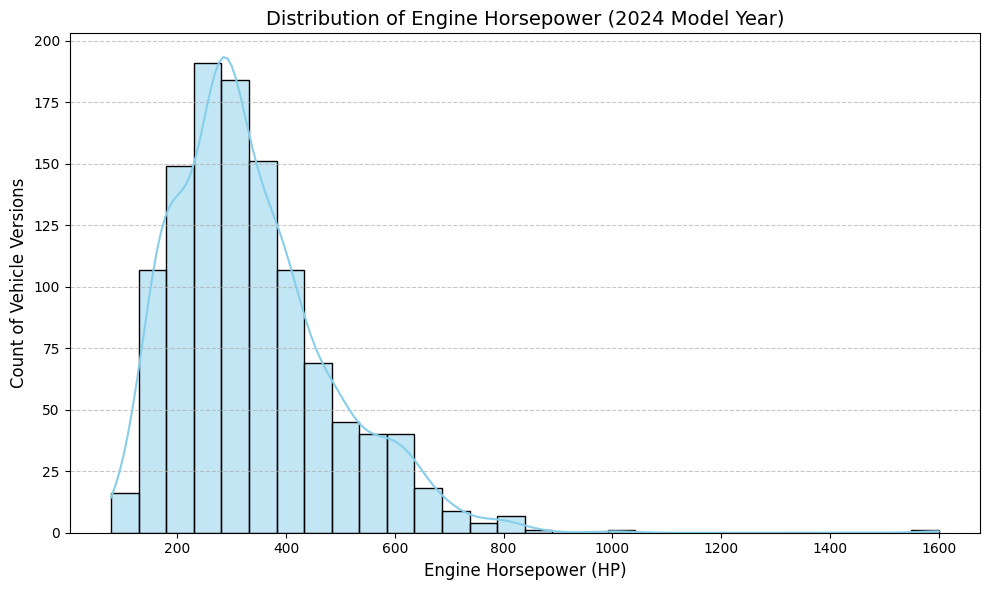

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# Safely load df from clean output, or rebuild it instantly if preceding cells weren't run
if 'df' not in globals():
    clean_path = os.path.join("data", "clean", "epa_my2024_clean.csv")
    if os.path.exists(clean_path):
        print(f"Loading cleaned dataframe from '{clean_path}'...")
        df = pd.read_csv(clean_path)
    else:
        print("Cleaned dataframe not found on disk. Building 'df' on-the-fly...")
        # Step 3: exact duplicates
        _df = raw.copy()
        _df = _df[~_df.duplicated(keep="first")]
        # Step 4: whitespace
        _df = _df.apply(lambda s: s.str.strip())
        _df = _df[~_df.duplicated(keep="first")]
        # Step 5: remove EV rows in kWh/100 mi
        _df = _df[~_df["FE_UNIT"].str.upper().str.contains("KW")]
        # Step 6: remove hybrid motor rows
        VEH_KEY = ["CAFE Mfr Code", "Carline Mfr Code", "DIVISION_CD", "CARLINE_CODE", "MODEL_TYPE_INDEX",
                   "BASE_LEVEL_INDEX", "CAFE Base Level Inertia Weight", "SBCNFG_CARLINE_TESTGROUP"]
        CORE_KEY = VEH_KEY + ["FE_UNIT", "Basic Engine Testgroup", "UNRD_5C_ADJ_MT_COMB_FE", "CARLINE_BASE_LEVEL_PROD_VOL"]
        srcs = _df.groupby(CORE_KEY)["DRIVE_SOURCE"].transform(lambda s: "".join(sorted(set(s))))
        motor_row = _df["DRIVE_SOURCE"].eq("E") & srcs.str.contains("C") & srcs.str.contains("E")
        _df = _df[~motor_row]
        # Step 7: keep only analysis columns
        _df = _df[list(KEEP)].copy()
        # Step 8: blank text to missing
        _df = _df.replace("", np.nan)
        # Step 9: rename
        _df = _df.rename(columns=KEEP)
        # Step 10: numeric conversion
        NUMERIC = {KEEP[c]: SHOULD_BE[c] for c in NUMERIC_RAW}
        for col, kind in NUMERIC.items():
            num = pd.to_numeric(_df[col], errors="coerce")
            if kind == "int" and (num.dropna() % 1 == 0).all():
                num = num.astype("Int64")
            _df[col] = num
        # Step 15: remove rows with no combined fuel economy
        _df = _df[~_df["comb_mpg"].isna()]
        df = _df
        print(f"Successfully generated 'df' ({len(df)} rows).")

# Filter out missing horsepower values for plotting
hp_data = df['engine_hp'].dropna()

# Create the histogram plot
fig = plt.figure(figsize=(10, 6))
sns.histplot(hp_data, bins=30, kde=True, color='skyblue', edgecolor='black')

# Add labels and title
plt.title("Distribution of Engine Horsepower (2024 Model Year)", fontsize=14)
plt.xlabel("Engine Horsepower (HP)", fontsize=12)
plt.ylabel("Count of Vehicle Versions", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

## 4. Row and column accounting

In [19]:
ROWS_CLEAN, COLS_CLEAN = df.shape
cols_dropped = COLS_RAW - len(KEEP)
cols_added = len([c for c in df.columns if c not in KEEP.values()])

assert ROWS_RAW - REMOVED["exact duplicates"] - REMOVED["near-duplicates"] - REMOVED["other"] == ROWS_CLEAN, "Rows do not reconcile"
assert COLS_RAW - cols_dropped + cols_added == COLS_CLEAN, "Columns do not reconcile"

print(f"""
Rows in raw file                      {ROWS_RAW:>6,}
Rows removed as exact duplicates      {REMOVED['exact duplicates']:>6,}   (log row: exact duplicates)
Rows removed as near-duplicates       {REMOVED['near-duplicates']:>6,}   (hybrid motor rows + whitespace-only duplicates)
Rows removed for other reasons        {REMOVED['other']:>6,}   (EV kWh/100 mi rows + rows with no combined MPG)
Rows in cleaned file                  {ROWS_CLEAN:>6,}

Columns in raw file                   {COLS_RAW:>6}
Columns dropped                       {cols_dropped:>6}   (not used in the analysis; see log)
Columns added                         {cols_added:>6}   (powertrain, flag_comb_outside_city_hwy, flag_class_drive_mismatch)
Columns in cleaned file               {COLS_CLEAN:>6}

Both totals reconcile (checked with assert).""")


Rows in raw file                       1,978
Rows removed as exact duplicates           0   (log row: exact duplicates)
Rows removed as near-duplicates          268   (hybrid motor rows + whitespace-only duplicates)
Rows removed for other reasons           283   (EV kWh/100 mi rows + rows with no combined MPG)
Rows in cleaned file                   1,427

Columns in raw file                      164
Columns dropped                          130   (not used in the analysis; see log)
Columns added                              3   (powertrain, flag_comb_outside_city_hwy, flag_class_drive_mismatch)
Columns in cleaned file                   37

Both totals reconcile (checked with assert).


## 5. Provenance Brief

In [20]:
n_makers = df["mfr_name"].nunique()
n_hybrid = int((df["powertrain"] == "Hybrid").sum())
n_gas = int((df["powertrain"] == "Gasoline").sum())

brief = f"""
This is a list of the new cars, SUVs, pickups and vans built for sale in the United States in the 2024 model year.
Each line is one version of one vehicle; a front-wheel-drive and an all-wheel-drive Honda CR-V, for example, are
separate lines. After cleaning there are {ROWS_CLEAN:,} lines from {n_makers} carmakers, including {n_gas:,} gasoline
and {n_hybrid:,} hybrid versions.

The list comes from the U.S. Environmental Protection Agency. Carmakers must test their vehicles and report the results
to the agency, which uses them to check each company against federal fuel-economy and pollution limits and to write
its yearly Automotive Trends Report. The agency posted this part of the data in March 2026.

For each version the list gives the maker, model, size, engine, transmission, type of power (gasoline, hybrid,
plug-in or electric), its fuel-economy ratings and how many were built.

It can show whether 2024 hybrids were rated as more fuel-efficient than similar gasoline models. It cannot show what
owners actually get on the road, other years, prices or safety, and the test results are reported by the carmakers
themselves.
"""
display(Markdown(brief))
n_words = len(brief.split())
print(f"Word count: {n_words}")
assert n_words <= 200, "Provenance brief is over 200 words"


This is a list of the new cars, SUVs, pickups and vans built for sale in the United States in the 2024 model year.
Each line is one version of one vehicle; a front-wheel-drive and an all-wheel-drive Honda CR-V, for example, are
separate lines. After cleaning there are 1,427 lines from 27 carmakers, including 842 gasoline
and 69 hybrid versions.

The list comes from the U.S. Environmental Protection Agency. Carmakers must test their vehicles and report the results
to the agency, which uses them to check each company against federal fuel-economy and pollution limits and to write
its yearly Automotive Trends Report. The agency posted this part of the data in March 2026.

For each version the list gives the maker, model, size, engine, transmission, type of power (gasoline, hybrid,
plug-in or electric), its fuel-economy ratings and how many were built.

It can show whether 2024 hybrids were rated as more fuel-efficient than similar gasoline models. It cannot show what
owners actually get on the road, other years, prices or safety, and the test results are reported by the carmakers
themselves.


Word count: 181


## Save the cleaned data and log to `data/clean/`

In [21]:
OUT_DIR = os.path.join("data", "clean")
assert os.path.abspath(OUT_DIR) != os.path.abspath(os.path.join("data", "raw"))
os.makedirs(OUT_DIR, exist_ok=True)
df.to_csv(os.path.join(OUT_DIR, "epa_my2024_clean.csv"), index=False)
cleaning_log.to_csv(os.path.join(OUT_DIR, "cleaning_log.csv"))
print("Saved:", os.listdir(OUT_DIR))

Saved: ['epa_my2024_clean.csv', 'cleaning_log.csv']


## Self-Scored Rubric

Scale: 3 = strong, evidenced, specific; 2 = present but generic or asserted; 1 = weak or partial; 0 = missing. Weighted = score × weight.

| Criterion | Wt | Score | Weighted | Justification |
|---|---|---|---|---|
| Diagnosis & data dictionary | ×2 | 3 | 6 | Every analysis column profiled (dtype as loaded vs. should be, missing count and rate, distinct values, min/max/range, full level sets). 26 defect classes checked with counts, each marked found or not found. Dictionary gives type, units, levels, valid range, meaning of missing and notes for every variable, and flags contradictions (combined MPG outside city-highway range, 2WD size class on all-wheel-drive vehicles). |
| Cleaning execution | ×2 | 3 | 6 | Fixes target the question: one row per vehicle version (EV and hybrid double rows removed), one unit for MPG, a powertrain label that separates full hybrids from mild hybrids and plug-ins. Contradictions are flagged, not overwritten, with the alternatives stated. |
| Cleaning log | ×3 | 3 | 9 | One row per decision, each with an exact count computed at run time, a reason, what is lost (including "nothing"), and how to reverse it from the raw file. Decisions *not* to change data are logged too. |
| Provenance Brief | ×1 | 3 | 3 | Under 200 words, no jargon: what the list is, who made it, why, what it holds, and what it cannot show. |
| Tidy structure & reproducibility | ×2 | 3 | 6 | One row per vehicle version and one column per variable; runs top to bottom on a restarted kernel; reads raw data read-only and writes only to `data/clean/`; README and `data/raw/SOURCES.md` in the repo. |
| **Total** | | | **30 / 30** | |

## AI use note

I used Claude (Anthropic) to help structure this notebook, draft the audit and cleaning code. In P1 I used ChatGPT to help identify public automobile data sources.

Additionally, I used claude to understand which graph could help me visualize any key outliners for the upcoming milstone.

## P2 Checklist

- [x] Audit: dtype, missing, distinct, min/max/range, level sets for every analysis column
- [x] Defect classes checked for and **not** found are stated
- [x] Data dictionary: at least five variables, every analysis variable, contradictions flagged
- [x] Cleaning log: count, reason, what is lost, reversible, 10–20 rows
- [x] Row and column accounting reconciles (checked with `assert`)
- [x] Provenance Brief, 200 words maximum, no jargon
- [x] Notebook runs top to bottom on a restarted kernel
- [x] `README.md` in the repo; raw data unmodified in `data/raw/`, never written by the code
- [x] Self-scored rubric attached